In [10]:
import sys 
sys.path.append("/home/feity/cryoem/")
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import utils
import torch
import importlib 
import modules
import data
import modules
import postprocess 

import pickle
importlib.reload(data)

<module 'data' from '/home/feity/cryoem/data.py'>

In [ ]:
import data
dataset = data.MrcDataset(
    "/data/transformer_project/transforemer_model/train_data/training/newdata/sllt0039_interpolate_new.pkl",
    # "/data/transformer_project/transforemer_model/train_data/training/newdata/TS_031_interpolate.pkl",
    # "/data/transformer_project/transforemer_model/test_data/dxd20240920_hsp60/24092001.pkl", 
    # "/data/transformer_project/transforemer_model/train_data/training/newdata/TS_005_interpolate.pkl",
    norm="hist",
    reshape=1024,
    # map_class={"nucleus": 1 },
    map_class={"mitochondria": 0},
    # map_class={"nucleus": 1},
    gap=5,
    length_for_average=3,
    transform=data.getConstantTransform(),
    add_classname=True,
    mask_length=1,
    require_mask=True,
    filtermin=0
)

reading dataset: /data/transformer_project/transforemer_model/train_data/training/newdata/sllt0039_interpolate_new.pkl
dataset map classes:  {'nucleus': 1}
dataset length: 31


In [35]:
# Fallback scale bar (rectangle + text) for current axes 'ax'
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

def add_scalebar(ax, pixel_size_nm=1.0, bar_length_nm=100, location='lower right', color='white', pad_frac=0.03, height_frac=0.01, linewidth=0, fontsize=10, frameon=False, bg_alpha=0.6):
    bar_length_px = bar_length_nm / float(pixel_size_nm)
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    width = abs(x1 - x0)
    height = abs(y1 - y0)
    bar_h = max(1.0, height * height_frac)
    pad_x = width * pad_frac
    pad_y = height * pad_frac
    y_min, y_max = (min(y0, y1), max(y0, y1))
    x_min, x_max = (min(x0, x1), max(x0, x1))
    loc = (location or 'lower right').lower().strip()
    if loc == 'lower right':
        rx = x_max - pad_x - bar_length_px
        ry = y_min + pad_y
        text_ha, text_va = 'right', 'bottom'
        tx = rx + bar_length_px
        ty = ry + bar_h + (0.5 * pad_y)
    elif loc == 'lower left':
        rx = x_min + pad_x
        ry = y_min + pad_y
        text_ha, text_va = 'left', 'bottom'
        tx = rx
        ty = ry + bar_h + (0.5 * pad_y)
    elif loc == 'upper right':
        rx = x_max - pad_x - bar_length_px
        ry = y_max - pad_y - bar_h
        text_ha, text_va = 'right', 'top'
        tx = rx + bar_length_px
        ty = ry - (0.5 * pad_y)
    elif loc == 'upper left':
        rx = x_min + pad_x
        ry = y_max - pad_y - bar_h
        text_ha, text_va = 'left', 'top'
        tx = rx
        ty = ry - (0.5 * pad_y)
    else:
        rx = x_max - pad_x - bar_length_px
        ry = y_min + pad_y
        text_ha, text_va = 'right', 'bottom'
        tx = rx + bar_length_px
        ty = ry + bar_h + (0.5 * pad_y)
    rect = Rectangle((rx, ry), bar_length_px, bar_h, facecolor=color, edgecolor=color if linewidth > 0 else 'none', linewidth=linewidth, alpha=1.0)
    ax.add_patch(rect)
    text_kwargs = dict(color=color, fontsize=fontsize, ha=text_ha, va=text_va)
    if frameon:
        text_kwargs['bbox'] = dict(boxstyle='round,pad=0.2', fc='black', ec='none', alpha=bg_alpha)
    ax.text(tx, ty, f"{bar_length_nm} nm", **text_kwargs)
    return rect

# Example (use your current axes 'ax'):
# add_scalebar(ax, pixel_size_nm=0.5, bar_length_nm=100, location='lower right')

masks
BoundingBoxes([[  36.,  236.,  315., 1009.]], format=BoundingBoxFormat.XYXY, canvas_size=(1024, 1024))


' if use dbscan results '

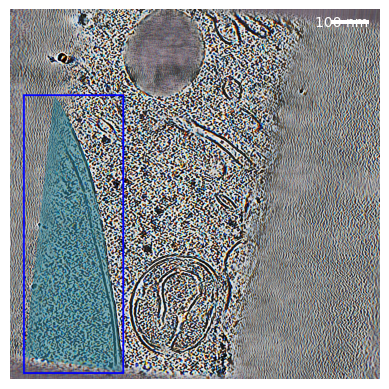

In [ ]:
import utils
import postprocess
import importlib
importlib.reload(postprocess)
importlib.reload(utils)
import torch
take = 200
# take = 295
# q = df["z"]

# subdf = df
# subdf = subdf[(subdf["label"] != "")]
# subdf = subdf[(subdf["item_id"] != "")]
# subdf = subdf[subdf["label_id"] != -1]
# subdf = subdf[(subdf["nucleus"] > 0.85)]
# subdf = subdf[subdf["z"] == take]
# print(subdf["label_id"].value_counts())
# subdf = subdf[subdf["ribo"] > 0.8]
# subdf = subdf[subdf["label"] == "nucleus"]

# img = retdict["images"][take]
img = dataset.__getitem__(pos=take)["pixel_values"]
img[0, :, :] = img[1, :, :]
img[2, :, :] = img[1, :, :]
t = dataset.__getitem__(pos=take)
utils.drawannotation(t["pixel_values"], t["labels"], mask=True, box=False, font_size=1)
ax = plt.gca()
add_scalebar(ax, pixel_size_nm=0.96, bar_length_nm=100, location='lower right')

plt.axis("off")
print(t["labels"]["bboxes"])
plt.savefig("/home/feity/cryoem/temp/result_1223/fig4_gth_nuc_180.pdf", dpi=1024)
# subdf2 = subdf.loc[need]
# subdf2 = subdf  

# subdf2 = df.loc[need2]

""" if use dbscan results """
# subdf2 = subdf2[subdf2["label"] != -1]
# subdf2["label"] = subdf2["label"].astype("str")
# print(subdf2.head())

# bboxes = subdf2[["x", "y", "w", "h"]].values
# print("fromdf", bboxes)
# bboxes = utils.convertBoxes(torch.tensor(bboxes))
# bboxes = torch.tensor(bboxes)*torch.tensor([img.shape[1], img.shape[2], img.shape[1], img.shape[2]])
# # bboxes, img.shape
# img[0] = img[1]
# img[2] = img[1]
# # subdf2["names"] = subdf2["label"] + subdf2["label_id"].astype("str")
# names = list(subdf2["label"])
# # print(names)
# labels = {"bboxes": bboxes, "labels": names} 
# print(bboxes)
# plt.figure(figsize=(16,16))
# utils.drawannotation(img, labels, font_size=10)
# plt.show()
# plt.close()


In [8]:
model = utils.loadModel("/data/transformer_project/transforemer_model/train_data/training/results/conditional_mrc_hsp60/mito_hsp60_fold6", "stage2/epoch=3-total_validate_loss=0.4630.ckpt")

Some weights of ConditionalDetrForObjectDetection were not initialized from the model checkpoint at microsoft/conditional-detr-resnet-50 and are newly initialized because the shapes did not match:
- class_labels_classifier.bias: found shape torch.Size([91]) in the checkpoint and torch.Size([2]) in the model instantiated
- class_labels_classifier.weight: found shape torch.Size([91, 256]) in the checkpoint and torch.Size([2, 256]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/home/feity/anaconda3/envs/pytorch/lib/python3.12/site-packages/torch/nn/modules/transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")
/home/feity/cryoem/u

model at stage  stage 1
model with output classes 3
model receiving class weights tensor([0.1000, 1.0000, 0.0100])
using consistency regularization coef 0.5
incompatible parameters ['additional_input_layer.layer1.weight', 'additional_input_layer.layer1.bias', 'additional_input_layer.layer2.weight', 'additional_input_layer.layer2.bias', 'gnn.conv1.lin_l.weight', 'gnn.conv1.lin_l.bias', 'gnn.conv1.lin_r.weight', 'gnn.conv2.lin_l.weight', 'gnn.conv2.lin_l.bias', 'gnn.conv2.lin_r.weight', 'gnn.conv3.lin_l.weight', 'gnn.conv3.lin_l.bias', 'gnn.conv3.lin_r.weight', 'gnn.cls_head.0.weight', 'gnn.cls_head.0.bias', 'gnn.cls_head.2.weight', 'gnn.cls_head.2.bias', 'gnn.box_head.0.weight', 'gnn.box_head.0.bias', 'gnn.box_head.2.weight', 'gnn.box_head.2.bias', 'gnn.edge_head.0.weight', 'gnn.edge_head.0.bias', 'gnn.edge_head.2.weight', 'gnn.edge_head.2.bias', 'gnn.edge_head.4.weight', 'cri.weight']
finish loading parameters


/home/feity/cryoem/utils.py:1136: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(os.path.join(path, checkpoint), map_location="cpu")["state_dict"]


incompatible parameters []
finish loading parameters


In [4]:
dataset = data.MrcDataset(
    "/data/transformer_project/transforemer_model/test_data/dxd20240920_hsp60/24092031_mito.pkl", 
    # "/data/transformer_project/transforemer_model/train_data/training/newdata/TS_031_interpolate.pkl",
    # "/data/transformer_project/transforemer_model/test_data/dxd20240920_hsp60/24092001.pkl", 
    # "/data/transformer_project/transforemer_model/train_data/training/newdata/TS_005_interpolate.pkl",
    norm="hist",
    reshape=800,
    # map_class={"mitochondria": 0, "nucleus": 1 },
    gap=1,
    length_for_average=3,
    transform=data.getConstantTransform(),
    add_classname=True,
    mask_length=1,
    require_mask=True,
    filtermin=0
)
df, graphs, masks = postprocess.generatedf(model, dataset, gap = 1, columns=["hsp60", "mitochondria", "None"], return_mask=True)

reading dataset: /data/transformer_project/transforemer_model/test_data/dxd20240920_hsp60/24092031_mito.pkl
dataset map classes:  {'hsp60': 0, 'mitochondria': 1}
dataset length: 220


100%|██████████| 220/220 [04:14<00:00,  1.16s/it]


finish dataset
build graph
prepare df
[tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        ...,


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
       

In [15]:
df["label"] = df["largest"] 
df

,z,x,y,w,h,hsp60,mitochondria,None,max,largest,annotation,item_id,label
0,154,0.418663,0.803748,0.029150,0.028361,0.224060,0.000002,0.775939,0.775939,None,4,,None
1,154,0.501180,0.062149,0.021699,0.021455,0.265824,0.000025,0.734150,0.734150,None,4,,None
2,154,0.457979,0.390745,0.033727,0.028026,0.213240,0.000006,0.786753,0.786753,None,4,,None
3,154,0.171476,0.140020,0.009101,0.010237,0.347839,0.000032,0.652129,0.652129,None,4,,None
4,154,0.172759,0.644320,0.039021,0.032661,0.398483,0.000046,0.601471,0.601471,None,4,,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...
50404,373,0.941539,0.758432,0.013908,0.014786,0.675129,0.000156,0.324715,0.675129,hsp60,4,,hsp60
50405,373,0.941702,0.962123,0.013029,0.040679,0.152512,0.000041,0.847447,0.847447,None,4,,None
50406,373,0.897643,0.564119,0.213317,0.813058,0.000015,0.918257,0.081729,0.918257,mitochondria,4,,mitochondria
50407,373,0.933523,0.810912,0.010153,0.010933,0.476893,0.000164,0.522944,0.522944,None,4,,None


In [19]:
import postprocess
importlib.reload(postprocess)

# pick out labels using clustering

df["unlabeled"] = True 
df["label"] = "" 
df["label_id"] = -1
df["largest"].value_counts()
params= {
    "endoplasmic_reticulum_or_Golgi":{"min_prob":0.5, "nms":0.6, "dbscan_prams":{"min_samples": 20, "eps": 0.5, "dis_penalty_coef": 1.0*(1/500), "dis_penalty_cutoff": 20}}, 
    "mitochondria":{"min_prob":0.4, "nms":0.2, "dbscan_prams":{"min_samples": 11, "eps": 0.5, "dis_penalty_coef": 1.0*(1/500), "dis_penalty_cutoff": 10}}, 
    "nucleus":{"min_prob":0.3, "nms":0.4, "dbscan_prams":{"min_samples": 11, "eps": 0.5, "dis_penalty_coef": 1.0*(1/500), "dis_penalty_cutoff": 10}}, 
    "ribo":{"min_prob":0.60, "nms":0.2, "dbscan_prams":{"min_samples":6, "eps": 0.5, "dis_penalty_coef": 2.0*(1/500), "dis_penalty_cutoff": 5, "enlarge": 0.03}}, 
    "hsp60":{"min_prob":0.4, "nms":0.2, "dbscan_prams":{"min_samples": 4, "eps": 0.5, "dis_penalty_coef": 2.0*(1/500), "dis_penalty_cutoff": 5, "enlarge": 0.03}}, 
}

mark_and_filter = {
    "nucleus":{"max_cnt":1, "remove_iou": 0.4, "min_samples":20}, 
    "mitochondria":{"max_cnt":10, "remove_iou": 0.6, "min_samples":20}, 
    "endoplasmic_reticulum_or_Golgi":{"max_cnt":20, "remove_iou": 0.8, "min_samples":20}, 
    "ribo":{"max_cnt":500, "remove_iou": 0.5, "min_samples":10}, 
    "hsp60":{"max_cnt":500, "remove_iou": 0.5, "min_samples":6}, 
}

subdfs = []
for i in ["mitochondria", "hsp60"]:
# for i in ["nucleus"]:
# for i in ["hsp60"]:
# for i in ["ribo"]:
    subdf = postprocess.processClass(df, i, **params[i], use_myscan=False)
    subdfs.append(subdf)
    postprocess.markFilter(df, i, subdf, **mark_and_filter[i])


11 0.5 0.002 10
number of instances in class  4
4 0.5 0.004 5
number of instances in class  794


In [22]:
df

,z,x,y,w,h,hsp60,mitochondria,None,max,largest,annotation,item_id,label,class_value,unlabeled,label_id
0,154,0.418663,0.803748,0.029150,0.028361,0.224060,0.000002,0.775939,0.775939,None,4,,,0.224060,True,-1
1,154,0.501180,0.062149,0.021699,0.021455,0.265824,0.000025,0.734150,0.734150,None,4,,,0.265824,True,-1
2,154,0.457979,0.390745,0.033727,0.028026,0.213240,0.000006,0.786753,0.786753,None,4,,,0.213240,True,-1
3,154,0.171476,0.140020,0.009101,0.010237,0.347839,0.000032,0.652129,0.652129,None,4,,,0.347839,True,-1
4,154,0.172759,0.644320,0.039021,0.032661,0.398483,0.000046,0.601471,0.601471,None,4,,,0.398483,True,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50404,373,0.941539,0.758432,0.013908,0.014786,0.675129,0.000156,0.324715,0.675129,hsp60,4,,,0.675129,True,-1
50405,373,0.941702,0.962123,0.013029,0.040679,0.152512,0.000041,0.847447,0.847447,None,4,,,0.152512,True,-1
50406,373,0.897643,0.564119,0.213317,0.813058,0.000015,0.918257,0.081729,0.918257,mitochondria,4,,,0.000015,False,-1
50407,373,0.933523,0.810912,0.010153,0.010933,0.476893,0.000164,0.522944,0.522944,None,4,,,0.476893,True,-1


/tmp/ipykernel_8838/49201658.py:33: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  bboxes = torch.tensor(bboxes)*torch.tensor([img.shape[1], img.shape[2], img.shape[1], img.shape[2]])
/home/feity/cryoem/utils.py:75: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  annotated_tensor = torch.tensor(annotated_tensor, dtype=torch.uint8)


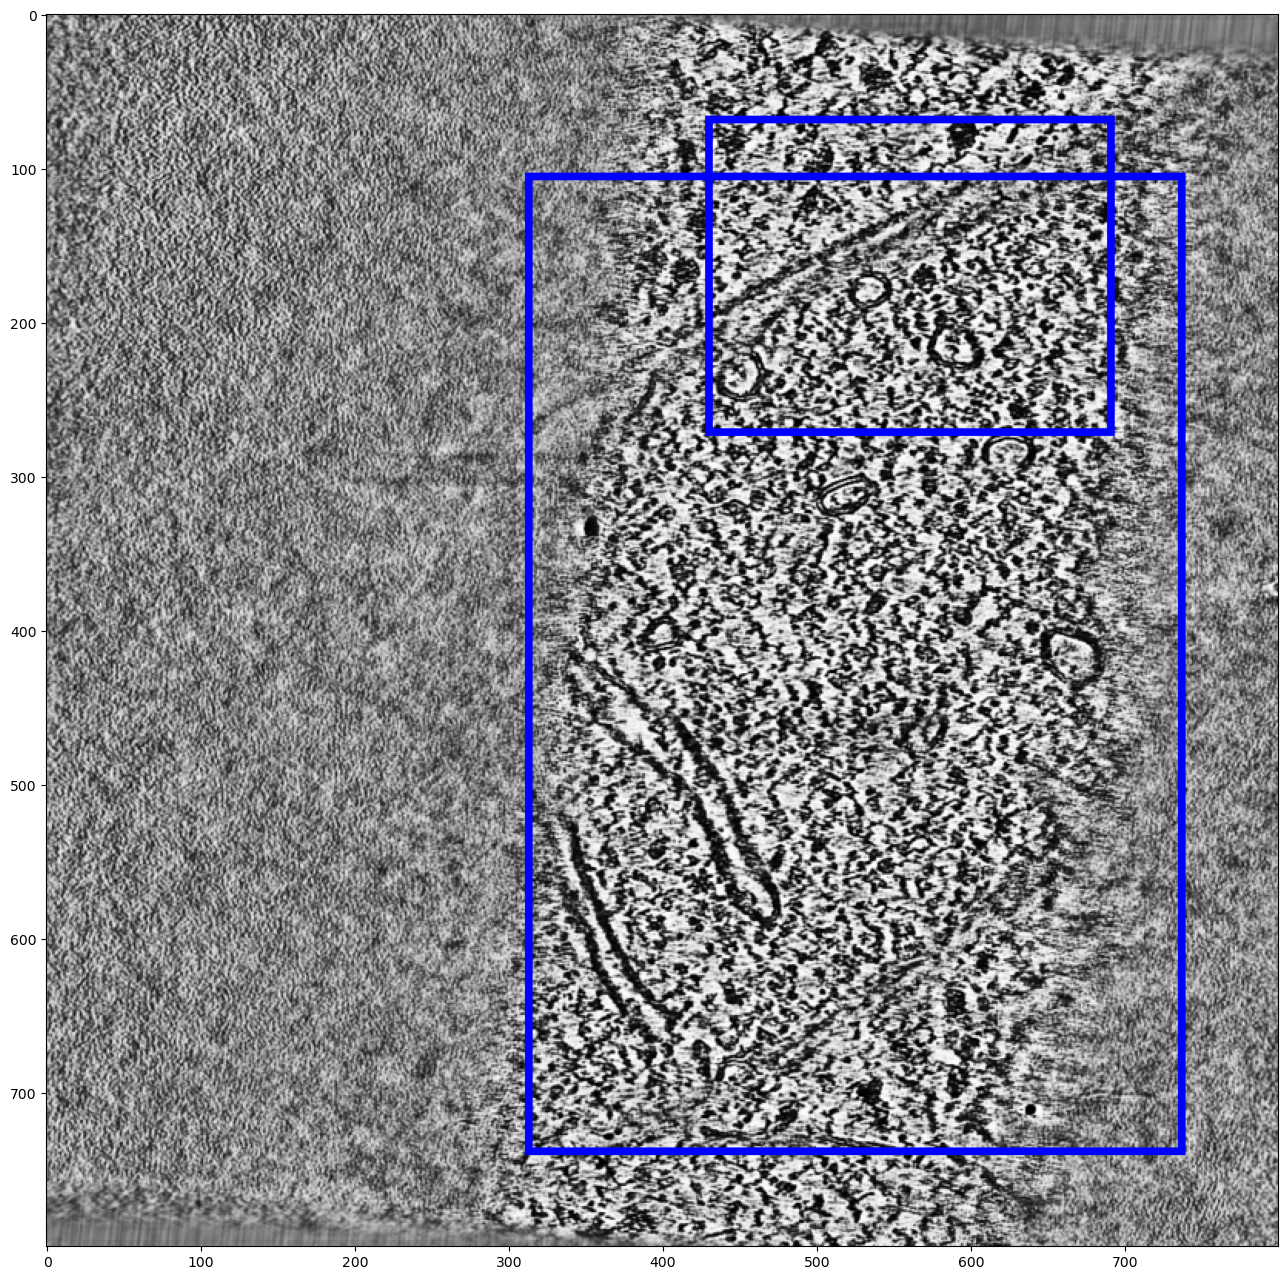

In [24]:
importlib.reload(postprocess)
importlib.reload(utils)
take = 250
q = df["z"]

subdf = df
subdf = subdf[subdf["largest"] == "mitochondria"]
subdf = subdf[subdf["mitochondria"] > 0.5]
# subdf = subdf[(subdf["label"] != "")]
# subdf = subdf[(subdf["item_id"] != "")]
# subdf = subdf[subdf["label_id"] != -1]
# subdf = subdf[(subdf["nucleus"] > 0.85)]
subdf = subdf[subdf["z"] == take]
# print(subdf["label_id"].value_counts())
# subdf = subdf[subdf["ribo"] > 0.8]
# subdf = subdf[subdf["label"] == "nucleus"]

# img = retdict["images"][take]
img = dataset.__getitem__(pos=take)["pixel_values"]

# subdf2 = subdf.loc[need]
subdf2 = subdf  

# subdf2 = df.loc[need2]

""" if use dbscan results """
subdf2 = subdf2[subdf2["label_id"] != -1]
# subdf2["label"] = subdf2["label"].astype("str")
# print(subdf2.head())

bboxes = subdf2[["x", "y", "w", "h"]].values
bboxes = utils.convertBoxes(torch.tensor(bboxes))
bboxes = torch.tensor(bboxes)*torch.tensor([img.shape[1], img.shape[2], img.shape[1], img.shape[2]])
# bboxes, img.shape
img[0] = img[1]
img[2] = img[1]
# subdf2["names"] = subdf2["label"] + subdf2["label_id"].astype("str")
names = list(subdf2["label"])
# print(names)
labels = {"bboxes": bboxes, "labels": names} 
plt.figure(figsize=(16,16))
utils.drawannotation(img, labels, font_size=10)
plt.show()
plt.close()


In [25]:
subdf2

,z,x,y,w,h,hsp60,mitochondria,None,max,largest,annotation,item_id,label,class_value,unlabeled,label_id
25825,250,0.701733,0.212480,0.318905,0.245830,0.001934,0.697705,0.300361,0.697705,mitochondria,4,,mitochondria,0.001934,False,2
25905,250,0.656848,0.527234,0.523365,0.783231,0.000004,0.940906,0.059090,0.940906,mitochondria,4,,mitochondria,0.000004,False,0


In [26]:
# df, graphs = postprocess.generatedf(model, dataset, gap = 5, columns=["mitochondria_memb", "None"])
all_y= [i.y for i in graphs]
all_y = np.concatenate(all_y, axis=0)
all_x = [i.x for i in graphs]
all_x = np.concatenate(all_x, axis=0)
all_box_mask = [i.box_masks for i in graphs]
all_box_mask = np.concatenate(all_box_mask, axis=0)
all_itemid = [i.item_id for i in graphs]
all_itemid = np.concatenate(all_itemid, axis=0)
mlabel = np.zeros_like(all_box_mask, dtype=np.int32)-1
cnt = 0
for i in range(len(mlabel)):
    if all_box_mask[i]:
        mlabel[i] = cnt
        cnt += 1
all_labels = [i.y.numpy() for i in graphs]
all_labels = np.concatenate(all_labels)
all_item_id = [i.item_id for i in graphs]
all_item_id = np.concatenate(all_item_id)
all_x = [i.x for i in graphs]
all_x = torch.cat(all_x, dim=0) 
df["annotation"] = all_labels
df["item_id"] = all_item_id
df["z"] = all_x[:, 0].numpy()*500
df["z"] = df["z"].round(0).astype(int)# df["item_id"] 

all_pv = {} 
for i in range(np.min(df["z"]), np.max(df["z"])+1):
    if i in all_pv:
        continue
    all_pv[i] = dataset.__getitem__(pos=i)["pixel_values"]


In [27]:
prepare_mask_input = {
    "nucleus":{"class_id":1, "min_length": 50, "extend": 10, "expand":0.03}, 
    "mitochondria":{"class_id":0, "min_length": 40, "extend": 10, "expand":0.03}, 
    "endoplasmic_reticulum_or_Golgi":{"class_id":3, "min_length": 30, "extend": 5, "expand":0.03}, 
    "ribo":{"class_id":0, "min_length": 20, "extend": 0, "expand":0.03}, 
    "hsp60":{"class_id":0, "min_length": 12, "extend": 0, "expand":0.03}, 
}
refine_mask = {
    "nucleus":{"smooth": 4.0, "morph_open_kernal_size":(7, 7), "morph_close_kernal_size": (7, 7), "blur_ksize": (25, 25), "max_contours": 1, "apply_convex_hull":False}, 
    "mitochondria":{"smooth": 4.0, "morph_open_kernal_size":(5, 5), "morph_close_kernal_size": (5, 5), "blur_ksize": (15, 15), "max_contours": 1, "apply_convex_hull":True}, 
    "endoplasmic_reticulum_or_Golgi":{"smooth": 1.0, "morph_open_kernal_size":(5, 5), "morph_close_kernal_size": (5, 5), "blur_ksize": (11, 11), "max_contours": 1, "contour_area_threshold":250, "apply_convex_hull":False}, 
    "ribo":{"smooth": 0.5, "morph_open_kernal_size":(3, 3), "morph_close_kernal_size": (3, 3), "blur_ksize": (3, 3), "max_contours": 1, "contour_area_threshold":10, "apply_convex_hull":False}, 
    "hsp60":{"smooth": 0.5, "morph_open_kernal_size":(3, 3), "morph_close_kernal_size": (3, 3), "blur_ksize": (3, 3), "max_contours": 1, "contour_area_threshold":10, "apply_convex_hull":False}, 
}
mask_thres = {
    "ribo":0.75, 
    "hsp60":0.75, 
    "mitochondria":0.6,
    "nucleus":0.5,
    "endoplasmic_reticulum_or_Golgi":0.6,
    
}

In [ ]:
all_res = {} 
before = {}
# gth = {}
# iou = {}

model.stage = "stage mask"
model.mask_head.TF = 1.0
model = model.cpu()
need = []
for i, r in df.groupby("item_id"):
    if not (i.startswith("nucleus") or i.startswith("mitochondria")):
        continue
    # print(i, len(r))
    inputs = {}  
    for j, row in r.iterrows():
        
        inputs[row["z"]] = {
            "id": j,
            "embed": all_x[j][-256:].unsqueeze(0).to(model.device),
            "bboxes": all_x[j][1:5].unsqueeze(0).to(model.device),
            "image": all_pv[row["z"]].unsqueeze(0).float().to(model.device),
            # "image": dataset.__getitem__(pos=row["z"])["pixel_values"].unsqueeze(0).float().to(model.device)
        }
        # if row["z"] == 290:
        #     need.append(inputs[row["z"]])
        #     print(j)
        # break
    # res = postprocess.getMasks(model, inputs, refine_mask[i.split("_")[0]]["smooth"], on_z_only=True)
    label = i[:i.rfind("_")]
    smoothed_masks = postprocess.getMasks(model, inputs, refine_mask[label]["smooth"], on_z_only=False)

    minz = np.min(list(inputs.keys()))
    maxz = np.max(list(inputs.keys()))
    t = np.max(smoothed_masks)
    # masks = [] 
    for i in range(len(smoothed_masks)):
        if i + minz not in inputs:
            continue
        
        pmask = smoothed_masks[i]
        before[inputs[i + minz]["id"]] = pmask
        # gth[inputs[i + minz]["id"]] = masks[mlabel[inputs[i + minz]["id"]]]
        # box = inputs[i + minz]["input_mask"]
        # t1 = (mask * box).sum() / box.sum()
        # t2 = (mask * (1 - box)).sum() / (1 - box).sum()
        thres = t*mask_thres[label]
        refined_mask = postprocess.refineMask(
            pmask,
            threshold = thres,
            **refine_mask[label],
        )
        # smoothed_masks[i] = refined_mask
        all_res[inputs[i + minz]["id"]] = refined_mask
        # iou[inputs[i + minz]["id"]] = postprocess.calc_iou(refined_mask, masks[mlabel[inputs[i + minz]["id"]]])
      

In [29]:
np.unique(df["item_id"])

array(['', 'hsp60_1', 'hsp60_10', 'hsp60_100', 'hsp60_101', 'hsp60_102',
       'hsp60_103', 'hsp60_104', 'hsp60_105', 'hsp60_106', 'hsp60_107',
       'hsp60_108', 'hsp60_109', 'hsp60_11', 'hsp60_110', 'hsp60_111',
       'hsp60_112', 'hsp60_113', 'hsp60_114', 'hsp60_115', 'hsp60_116',
       'hsp60_117', 'hsp60_118', 'hsp60_119', 'hsp60_12', 'hsp60_120',
       'hsp60_121', 'hsp60_122', 'hsp60_123', 'hsp60_124', 'hsp60_125',
       'hsp60_126', 'hsp60_127', 'hsp60_128', 'hsp60_129', 'hsp60_13',
       'hsp60_130', 'hsp60_131', 'hsp60_132', 'hsp60_133', 'hsp60_134',
       'hsp60_135', 'hsp60_136', 'hsp60_137', 'hsp60_138', 'hsp60_139',
       'hsp60_14', 'hsp60_140', 'hsp60_141', 'hsp60_142', 'hsp60_15',
       'hsp60_16', 'hsp60_17', 'hsp60_18', 'hsp60_19', 'hsp60_2',
       'hsp60_20', 'hsp60_21', 'hsp60_22', 'hsp60_23', 'hsp60_24',
       'hsp60_25', 'hsp60_26', 'hsp60_27', 'hsp60_28', 'hsp60_29',
       'hsp60_3', 'hsp60_30', 'hsp60_31', 'hsp60_32', 'hsp60_33',
       'hsp60_34',

In [30]:
a2 = np.zeros((500, 800, 800))
b2 = np.zeros((500, 800, 800))
zpos = list(df["z"])
for i, item in enumerate(list(df["item_id"])):
    if item == "mitochondria_1":
        a2[zpos[i]] = before[i]
        b2[zpos[i]] = all_res[i]

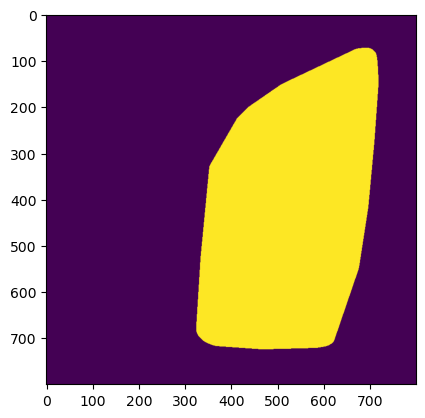

In [33]:
plt.imshow(b2[250])

In [9]:
a = np.zeros((500, 800, 800))
b = np.zeros((500, 800, 800))
zpos = list(df["z"])
for i, item in enumerate(list(df["item_id"])):
    if item == "mitochondria_1":
        a[zpos[i]] = before[i]
        b[zpos[i]] = all_res[i]

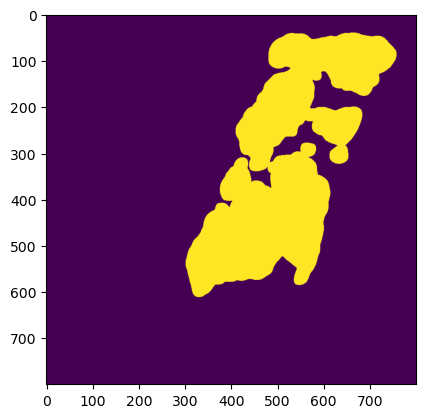

In [11]:
plt.imshow(b[290])

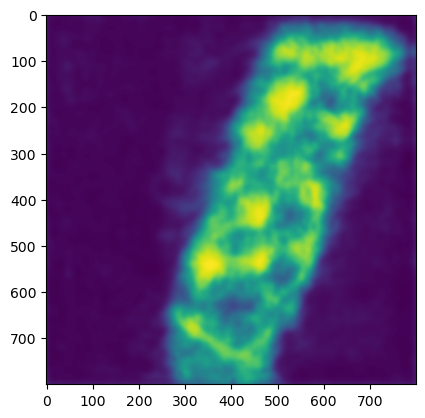

In [10]:
plt.imshow(a[290])